In [7]:
import pandas as pd

df_eda = pd.read_csv("feature_engineered_data.csv")
df_eda.head()

,Customer ID,Subscription Length (Months),Customer Satisfaction Score (1-10),Daily Watch Time (Hours),Engagement Rate (1-10),Device Used Most Often,Genre Preference,Region,Payment History (On-Time/Delayed),Subscription Plan,Churn Status (Yes/No),Support Queries Logged,Age,Monthly Income ($),Promotional Offers Used,Number of Profiles Created
0,C00001,12,10,4.85,4,Tablet,Action,Europe,On-Time,Basic,No,10,33,6250,5,2
1,C00002,12,8,1.75,9,Laptop,Thriller,Europe,On-Time,Basic,Yes,9,28,7018,1,5
2,C00003,3,4,2.75,9,Smart TV,Comedy,Asia,On-Time,Premium,Yes,3,18,1055,1,5
3,C00004,3,7,3.00,9,Smart TV,Drama,Europe,Delayed,Premium,No,5,32,6707,5,4
4,C00005,24,2,1.37,5,Mobile,Drama,North America,On-Time,Standard,Yes,2,59,1506,3,5


In [8]:
df_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Customer ID                         1000 non-null   str    
 1   Subscription Length (Months)        1000 non-null   int64  
 2   Customer Satisfaction Score (1-10)  1000 non-null   int64  
 3   Daily Watch Time (Hours)            1000 non-null   float64
 4   Engagement Rate (1-10)              1000 non-null   int64  
 5   Device Used Most Often              1000 non-null   str    
 6   Genre Preference                    1000 non-null   str    
 7   Region                              1000 non-null   str    
 8   Payment History (On-Time/Delayed)   1000 non-null   str    
 9   Subscription Plan                   1000 non-null   str    
 10  Churn Status (Yes/No)               1000 non-null   str    
 11  Support Queries Logged              1000 non-null   int

In [9]:
target_candidates = [col for col in df_eda.columns 
                     if 'churn' in col.lower() 
                     or 'cancel' in col.lower() 
                     or 'active' in col.lower()]

target_col = target_candidates[0]

target_col

'Churn Status (Yes/No)'

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

df_eda[target_col].value_counts()


Churn Status (Yes/No)
Yes    539
No     461
Name: count, dtype: int64

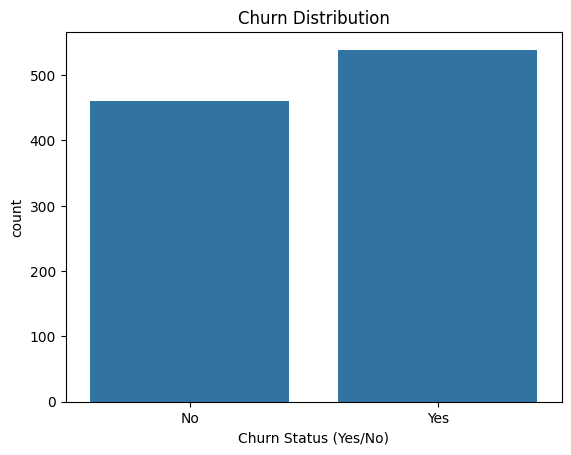

In [11]:
sns.countplot(x=target_col, data=df_eda)
plt.title("Churn Distribution")
plt.show()

### 📌 Insight
We observe imbalance in churn distribution.

👉 This means churn is behavior-driven, not random  
👉 Some users are significantly more likely to churn than others

In [15]:
df_eda.columns

Index(['Customer ID', 'Subscription Length (Months)',
       'Customer Satisfaction Score (1-10)', 'Daily Watch Time (Hours)',
       'Engagement Rate (1-10)', 'Device Used Most Often', 'Genre Preference',
       'Region', 'Payment History (On-Time/Delayed)', 'Subscription Plan',
       'Churn Status (Yes/No)', 'Support Queries Logged', 'Age',
       'Monthly Income ($)', 'Promotional Offers Used',
       'Number of Profiles Created'],
      dtype='str')

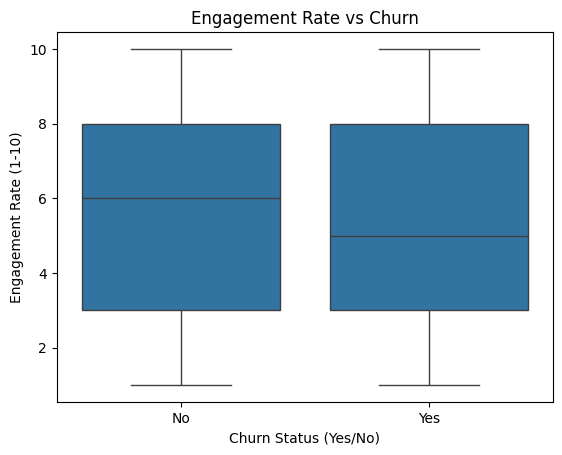

In [17]:
sns.boxplot(x=target_col, y='Engagement Rate (1-10)', data=df_eda)
plt.title("Engagement Rate vs Churn")
plt.show()

- Lower engagement users churn more
- Engagement is a strong retention indicator

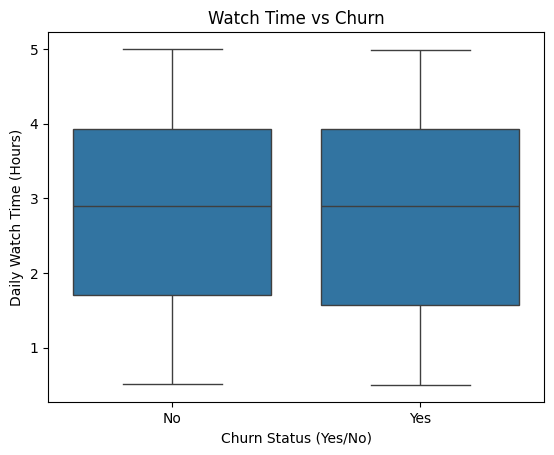

In [18]:
sns.boxplot(x=target_col, y='Daily Watch Time (Hours)', data=df_eda)
plt.title("Watch Time vs Churn")
plt.show()

- Users with low watch time are more likely to churn
- Heavy users are more retained

In [ ]:
sns.countplot(x='Subscription Plan', hue=target_col, data=df_eda)
plt.xticks(rotation=45)
plt.title("Subscription Plan vs Churn")
plt.show()